## 🌓 02. CLAHE 시인성 및 전처리 효과 분석

대조도가 흐릿한 임상 X-ray 사진의 병변 시인성을 높이기 위해 적용되는 적응형 히스토그램 평활화(CLAHE)의 효과를 정량/정성 평가합니다.

### 🎯 주요 분석 내용
- **파라미터 튜닝**: `clipLimit`, `tileGridSize`의 변화가 이미지에 미치는 영향 확인
- **정성적 검토**: Nodule, Effusion 등 모호한 폐 윤곽 병변이 뚜렷해지는지 샘플 이미지 눈으로 확인


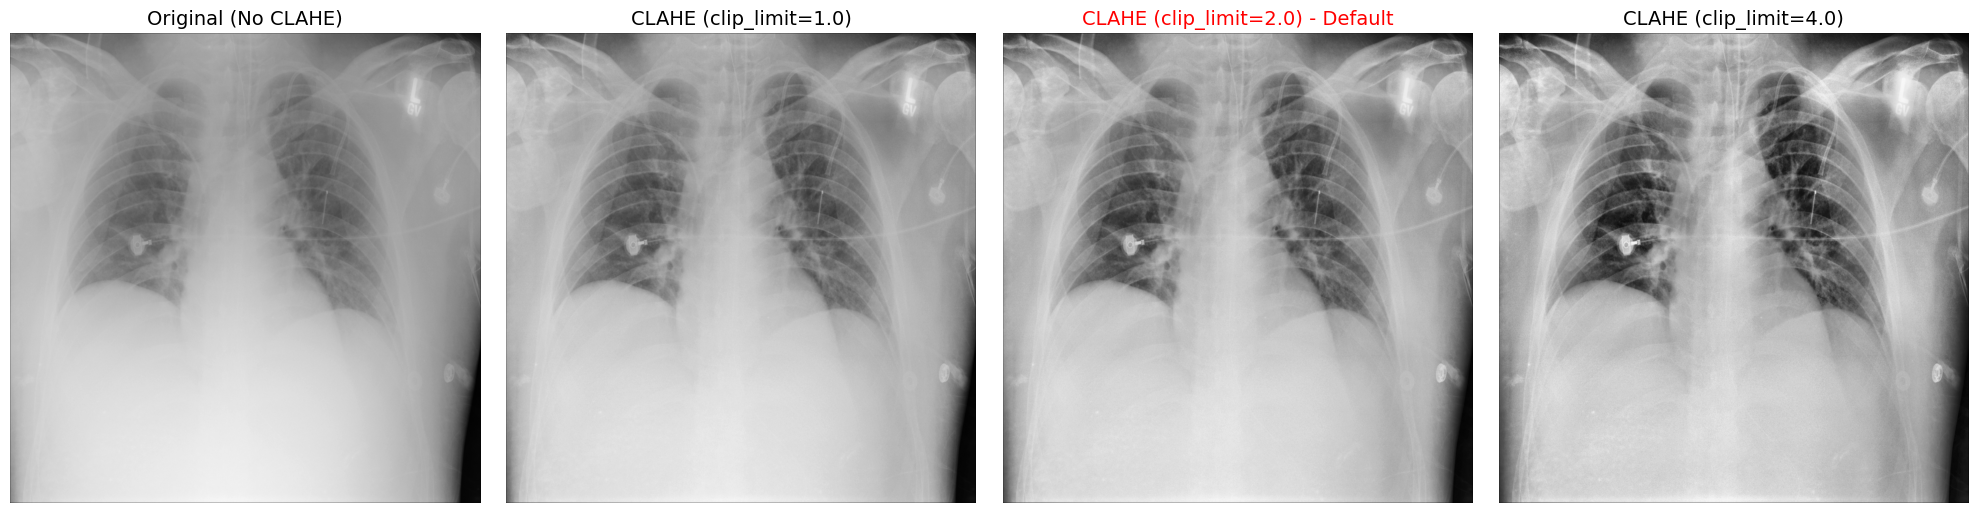

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from PIL import Image

# 1. 테스트용 이미지 하나 무작위로 불러오기
image_paths = glob.glob('../data/**/*.png', recursive=True)
test_image_path = np.random.choice(image_paths)

# 이미지를 흑백 모드로 읽어오기
img = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)

# 2. CLAHE 생성 (clip_limit을 3가지 버전으로 준비)
clahe_1 = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))
clahe_2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_4 = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))

# 3. 이미지에 CLAHE 적용
img_clahe_1 = clahe_1.apply(img)
img_clahe_2 = clahe_2.apply(img)
img_clahe_4 = clahe_4.apply(img)

# 4. 결과 시각화
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (No CLAHE)', fontsize=14)

axes[1].imshow(img_clahe_1, cmap='gray')
axes[1].set_title('CLAHE (clip_limit=1.0)', fontsize=14)

axes[2].imshow(img_clahe_2, cmap='gray')
axes[2].set_title('CLAHE (clip_limit=2.0) - Default', fontsize=14, color='red')

axes[3].imshow(img_clahe_4, cmap='gray')
axes[3].set_title('CLAHE (clip_limit=4.0)', fontsize=14)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()